In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
from config.db_config import DB_CONFIG, CONNECTION_STRING

print(DB_CONFIG)

{'server': 'DESKTOP-A39MPDE\\SQLEXPRESS', 'database': 'olist_db', 'driver': 'ODBC Driver 17 for SQL Server'}


In [6]:
from sqlalchemy import create_engine

engine = create_engine(CONNECTION_STRING)

with engine.connect() as conn:
    print("✅ Connected to SQL Server!")

✅ Connected to SQL Server!


In [7]:
import pandas as pd

fact_columns = pd.read_sql(
    "SELECT TOP 0 * FROM dbo.fact_orders",
    engine
)

print(fact_columns.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_delivered', 'delivery_days', 'delay_days', 'is_late', 'delay_bucket', 'order_month', 'order_year', 'order_hour', 'order_dayofweek', 'order_yearmonth', 'revenue_per_order', 'primary_payment_type', 'max_installments', 'review_score', 'customer_unique_id', 'customer_state', 'product_category_name_english']


In [10]:
csv_df = pd.read_csv(
    "../data/processed/master_orders.csv"
)

sql_count = pd.read_sql(
    "SELECT COUNT(*) AS count FROM dbo.fact_orders",
    engine
).iloc[0]["count"]

print("CSV rows:", len(csv_df))
print("SQL rows:", sql_count)

print("\nCSV columns:", len(csv_df.columns))
print("SQL columns:", len(fact_columns.columns))

print("\nColumns in CSV but NOT in SQL:")
print(sorted(set(csv_df.columns) - set(fact_columns.columns)))

print("\nColumns in SQL but NOT in CSV:")
print(sorted(set(fact_columns.columns) - set(csv_df.columns)))

CSV rows: 96470
SQL rows: 96470

CSV columns: 25
SQL columns: 25

Columns in CSV but NOT in SQL:
[]

Columns in SQL but NOT in CSV:
[]


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# 1. Create the folder to save our PNG charts
os.makedirs('../outputs/charts', exist_ok=True)

# 2. Load our Single Source of Truth
print("Loading master dataset...")
df = pd.read_csv('../data/processed/master_orders.csv')

# Convert ALL date columns back to datetime objects up front.
# NOTE: previously only 3 of these 5 columns were converted here, and
# order_approved_at / order_delivered_carrier_date were left as strings
# until a cell near the bottom of the notebook. That's fragile -- any
# earlier cell that touched those columns would silently do string
# comparisons instead of datetime math. Converting everything here means
# every column is safe to use from the first cell onward.
time_cols = [
    'order_purchase_timestamp', 'order_estimated_delivery_date',
    'order_delivered_customer_date', 'order_approved_at',
    'order_delivered_carrier_date'
]
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

print(f"Loaded {len(df):,} rows.")

# 2b. Map state codes to full names for readability in charts.
# Raw two-letter codes (RR, TO, SE, etc.) aren't intuitive to most
# readers -- this gives every chart the option to use a proper name.
state_mapping = {
    'SP': 'São Paulo', 'BA': 'Bahia', 'GO': 'Goiás', 'RN': 'Rio Grande do Norte',
    'PR': 'Paraná', 'RJ': 'Rio de Janeiro', 'RS': 'Rio Grande do Sul', 'MG': 'Minas Gerais',
    'SC': 'Santa Catarina', 'RR': 'Roraima', 'PE': 'Pernambuco', 'TO': 'Tocantins',
    'CE': 'Ceará', 'DF': 'Distrito Federal', 'SE': 'Sergipe', 'MT': 'Mato Grosso',
    'PB': 'Paraíba', 'PA': 'Pará', 'RO': 'Rondônia', 'ES': 'Espírito Santo',
    'AP': 'Amapá', 'MS': 'Mato Grosso do Sul', 'MA': 'Maranhão', 'PI': 'Piauí',
    'AL': 'Alagoas', 'AC': 'Acre', 'AM': 'Amazonas'
}
df['state_full_name'] = df['customer_state'].map(state_mapping)

# NOTE: state_mapping only covers the 27 official Brazilian states/DF.
# If customer_state ever contains anything outside that set (a bad
# code, a typo, a future new value), .map() silently produces NaN for
# those rows rather than erroring. Checking now so it's not a silent
# surprise in a chart later.
unmapped = df.loc[df['state_full_name'].isna(), 'customer_state'].unique()
if len(unmapped) > 0:
    print(f"⚠️ {len(unmapped)} state code(s) not in state_mapping: {list(unmapped)}")
else:
    print("✓ All customer_state values mapped to a full name.")

# 3. Define a unified color palette for professional BA presentation
brand_color = '#1f77b4'  
accent_color = '#2ca02c' 
danger_color = '#ff7f0e' 

# Set the background style to clean and minimalist
sns.set_theme(style="whitegrid")

Loading master dataset...
Loaded 96,470 rows.
✓ All customer_state values mapped to a full name.


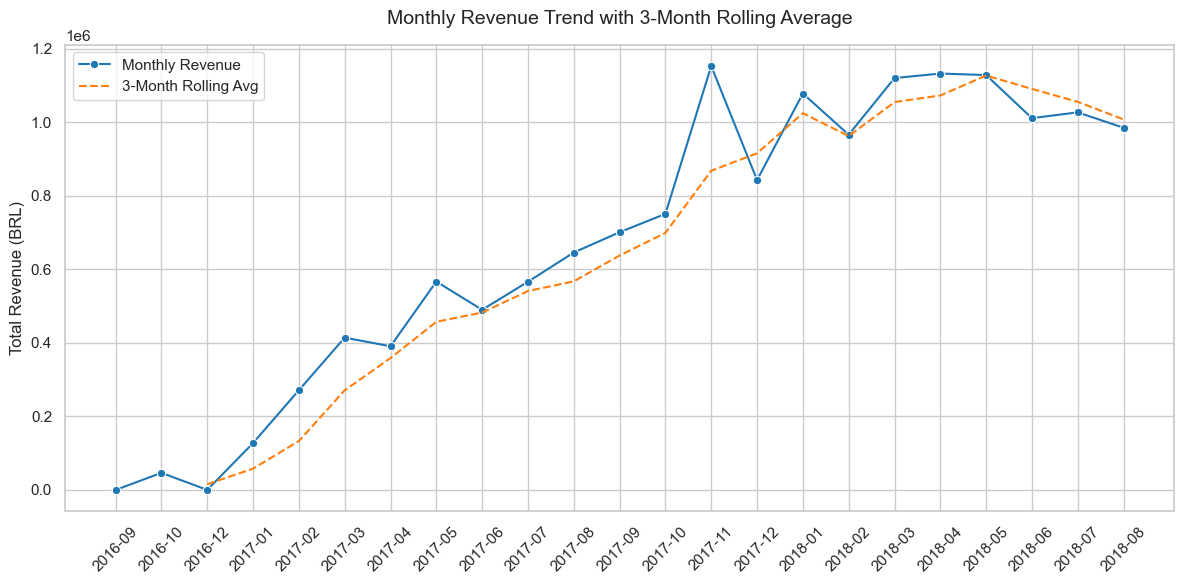

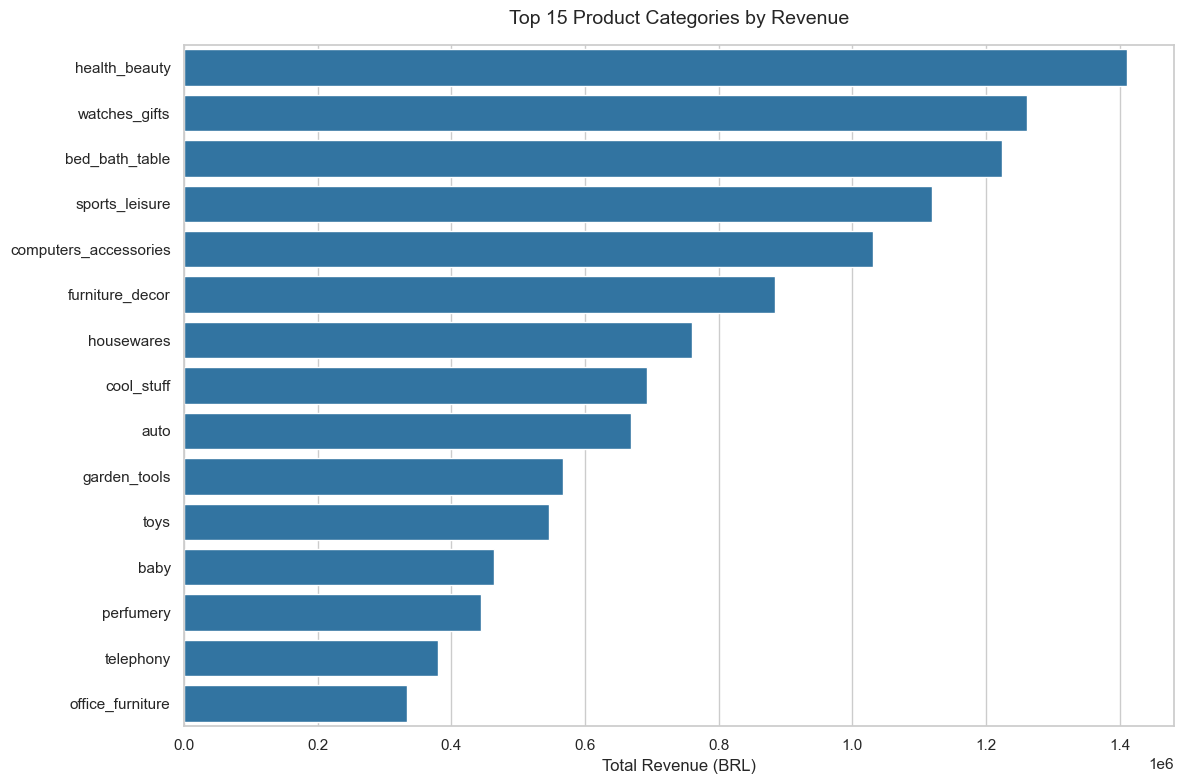

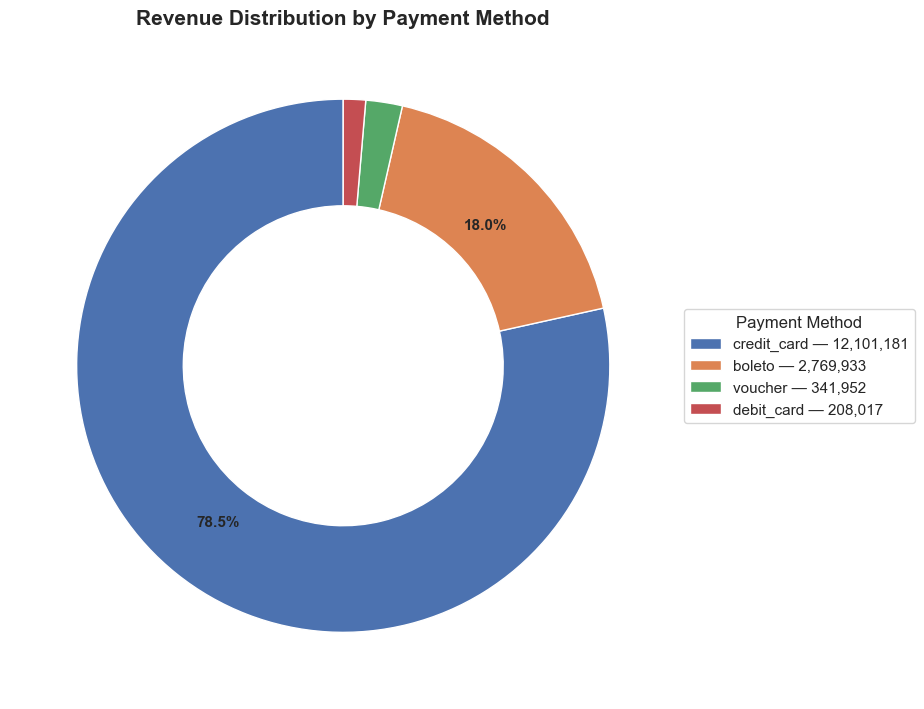

In [10]:
# ==========================================
# CHART 1: Monthly Revenue Trend
# ==========================================
plt.figure(figsize=(12, 6))

monthly_rev = df.groupby('order_yearmonth')['revenue_per_order'].sum().reset_index()

sns.lineplot(data=monthly_rev, x='order_yearmonth', y='revenue_per_order', 
             marker='o', color=brand_color, label='Monthly Revenue')

monthly_rev['rolling_3m'] = monthly_rev['revenue_per_order'].rolling(window=3).mean()
sns.lineplot(data=monthly_rev, x='order_yearmonth', y='rolling_3m', 
             color=danger_color, linestyle='--', label='3-Month Rolling Avg')

plt.title('Monthly Revenue Trend with 3-Month Rolling Average', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.ylabel('Total Revenue (BRL)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../outputs/charts/01_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 2: Top 15 Categories by Revenue
# ==========================================
plt.figure(figsize=(12, 8))

cat_rev = df.groupby('product_category_name_english')['revenue_per_order'].sum().sort_values(ascending=False).head(15)

sns.barplot(x=cat_rev.values, y=cat_rev.index, color=brand_color)

plt.title('Top 15 Product Categories by Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/charts/02_top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 3: Payment Method Breakdown
# ==========================================

pay_rev = (
    df.groupby('primary_payment_type')['revenue_per_order']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 8))

wedges, texts, autotexts = plt.pie(
    pay_rev.values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p >= 3 else '',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

# Improve percentage text
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

# Legend
plt.legend(
    wedges,
    [f'{method} — {value:,.0f}' 
     for method, value in pay_rev.items()],
    title='Payment Method',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title(
    'Revenue Distribution by Payment Method',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../outputs/charts/03_payment_methods.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

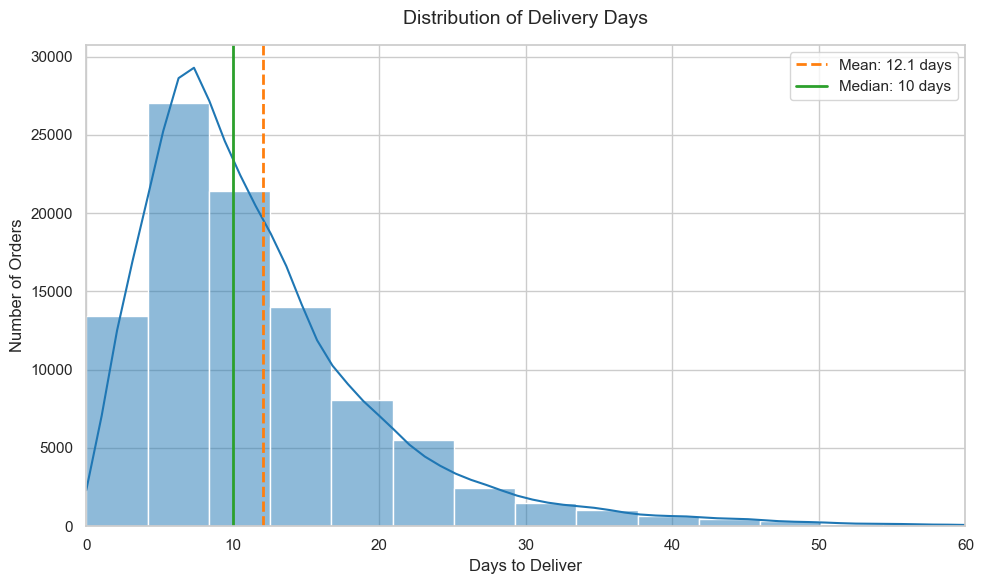

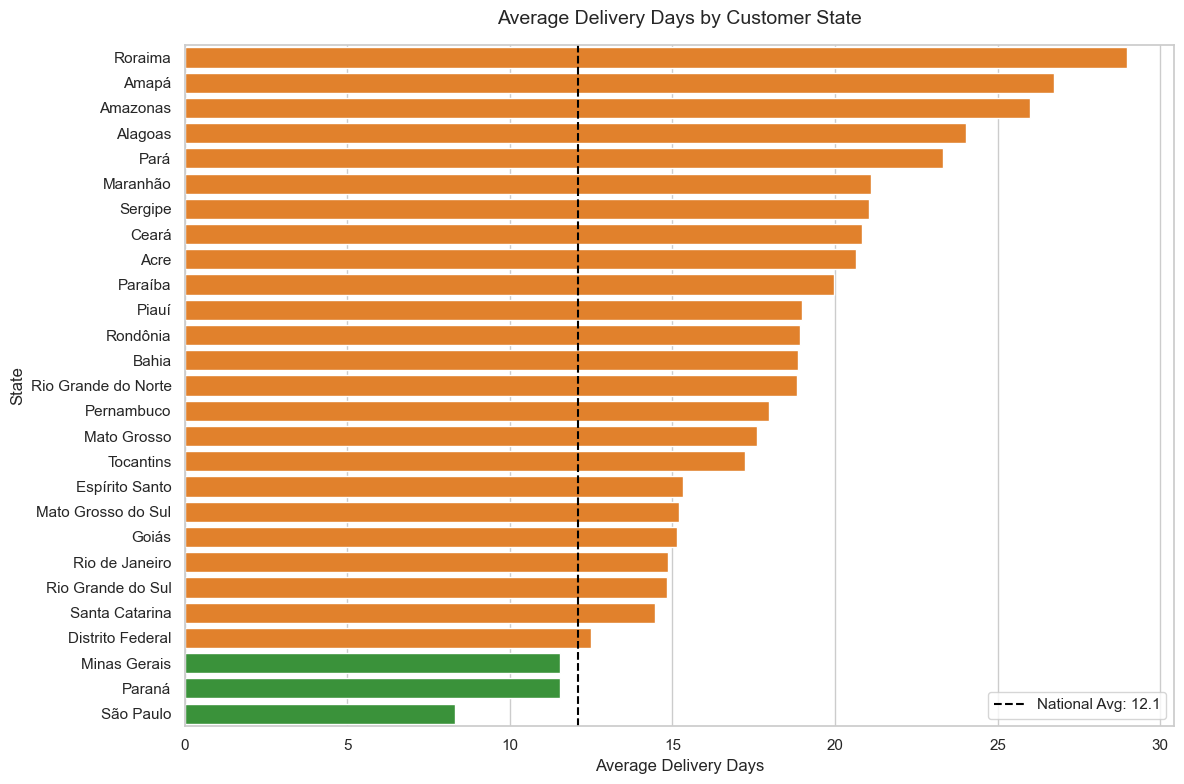

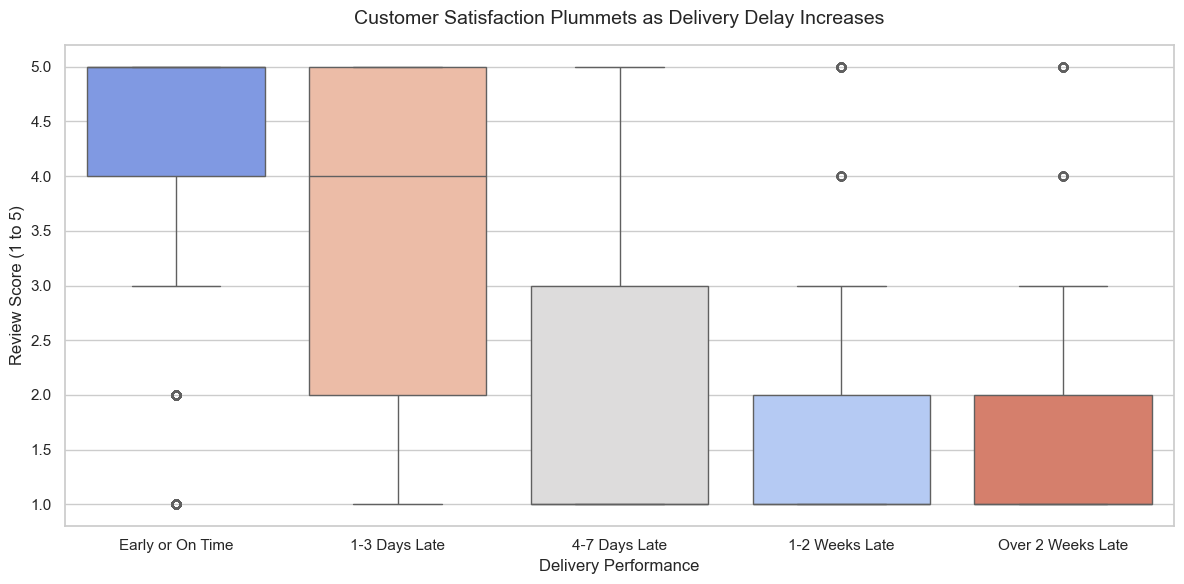

In [11]:
# ==========================================
# CHART 4: Delivery Days Distribution
# ==========================================
plt.figure(figsize=(10, 6))

delivery_data = df['delivery_days'].dropna()

sns.histplot(delivery_data, bins=50, color=brand_color, kde=True)

plt.axvline(delivery_data.mean(), color=danger_color, linestyle='dashed', linewidth=2, label=f'Mean: {delivery_data.mean():.1f} days')
plt.axvline(delivery_data.median(), color=accent_color, linestyle='solid', linewidth=2, label=f'Median: {delivery_data.median():.0f} days')

plt.title('Distribution of Delivery Days', fontsize=14, pad=15)
plt.xlabel('Days to Deliver')
plt.ylabel('Number of Orders')
plt.xlim(0, 60)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/04_delivery_days_dist.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 5: Average Delivery Days by State
# ==========================================
plt.figure(figsize=(12, 8))

state_avg = df.groupby('state_full_name')['delivery_days'].mean().sort_values(ascending=False)
national_avg = df['delivery_days'].mean()

colors = [danger_color if val > national_avg else accent_color for val in state_avg.values]

sns.barplot(x=state_avg.values, y=state_avg.index, hue=state_avg.index, palette=colors, legend=False)
plt.axvline(national_avg, color='black', linestyle='--', label=f'National Avg: {national_avg:.1f}')

plt.title('Average Delivery Days by Customer State', fontsize=14, pad=15)
plt.xlabel('Average Delivery Days')
plt.ylabel('State')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/05_state_delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 6: Review Score vs. Delay Bucket
# ==========================================
plt.figure(figsize=(12, 6))

bucket_order = ['Early or On Time', '1-3 Days Late', '4-7 Days Late', '1-2 Weeks Late', 'Over 2 Weeks Late']

sns.boxplot(data=df, x='delay_bucket', y='review_score', order=bucket_order, hue='delay_bucket', palette='coolwarm', legend=False)

plt.title('Customer Satisfaction Plummets as Delivery Delay Increases', fontsize=14, pad=15)
plt.xlabel('Delivery Performance')
plt.ylabel('Review Score (1 to 5)')
plt.tight_layout()
plt.savefig('../outputs/charts/06_review_vs_delay.png', dpi=150, bbox_inches='tight')
plt.show()

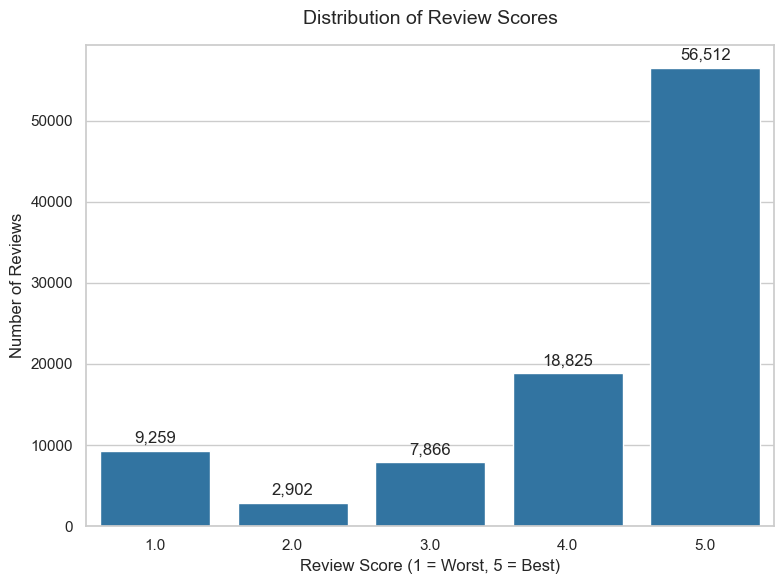

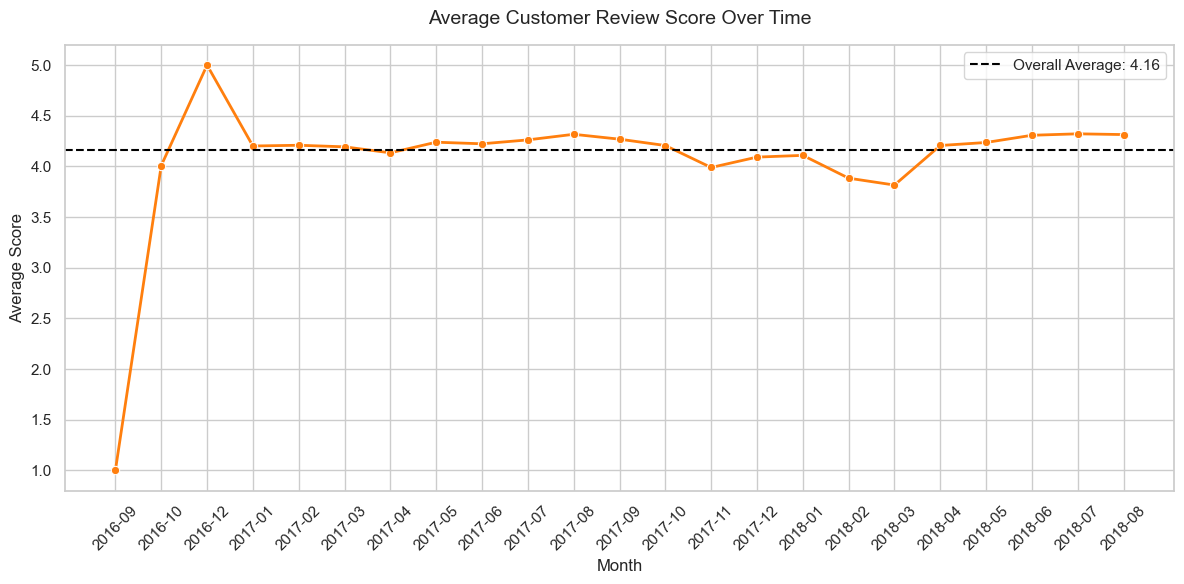

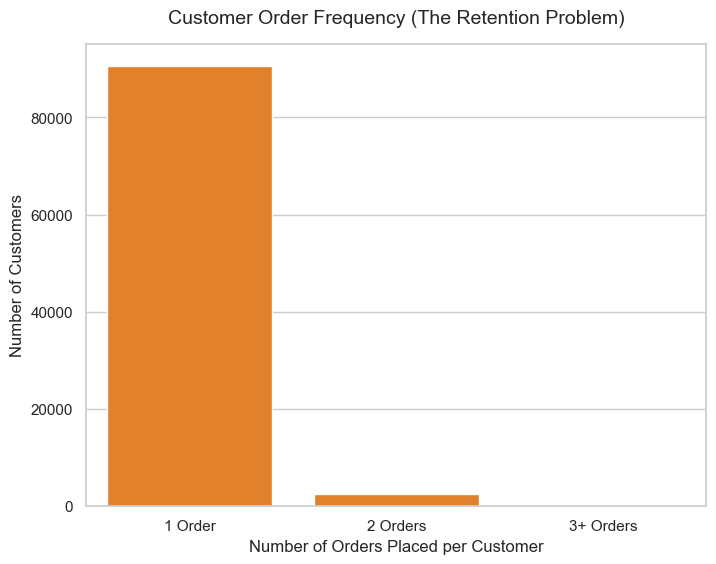

Shocking Stat: 97.0% of our customers never made a second purchase.


In [12]:
# ==========================================
# CHART 7: Overall Review Score Distribution
# ==========================================
plt.figure(figsize=(8, 6))

score_counts = df['review_score'].value_counts().sort_index()

sns.barplot(x=score_counts.index, y=score_counts.values, color=brand_color)

plt.title('Distribution of Review Scores', fontsize=14, pad=15)
plt.xlabel('Review Score (1 = Worst, 5 = Best)')
plt.ylabel('Number of Reviews')

for i, v in enumerate(score_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig('../outputs/charts/07_review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 8: Monthly Average Review Score Trend
# ==========================================
plt.figure(figsize=(12, 6))

monthly_score = df.groupby('order_yearmonth')['review_score'].mean().reset_index()

sns.lineplot(data=monthly_score, x='order_yearmonth', y='review_score', 
             marker='o', color=danger_color, linewidth=2)

overall_avg_score = df['review_score'].mean()
plt.axhline(overall_avg_score, color='black', linestyle='--', label=f'Overall Average: {overall_avg_score:.2f}')

plt.title('Average Customer Review Score Over Time', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.ylabel('Average Score')
plt.xlabel('Month')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/08_score_trend.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 9: Customer Order Frequency (Retention)
# ==========================================
plt.figure(figsize=(8, 6))

customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

freq_counts = customer_orders.value_counts()
buckets = {
    '1 Order': freq_counts.get(1, 0),
    '2 Orders': freq_counts.get(2, 0),
    '3+ Orders': freq_counts[freq_counts.index >= 3].sum()
}

sns.barplot(x=list(buckets.keys()), y=list(buckets.values()), color=danger_color)

plt.title('Customer Order Frequency (The Retention Problem)', fontsize=14, pad=15)
plt.xlabel('Number of Orders Placed per Customer')
plt.ylabel('Number of Customers')

total_customers = len(customer_orders)
single_order_pct = (buckets['1 Order'] / total_customers) * 100

plt.savefig('../outputs/charts/09_customer_retention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Shocking Stat: {single_order_pct:.1f}% of our customers never made a second purchase.")

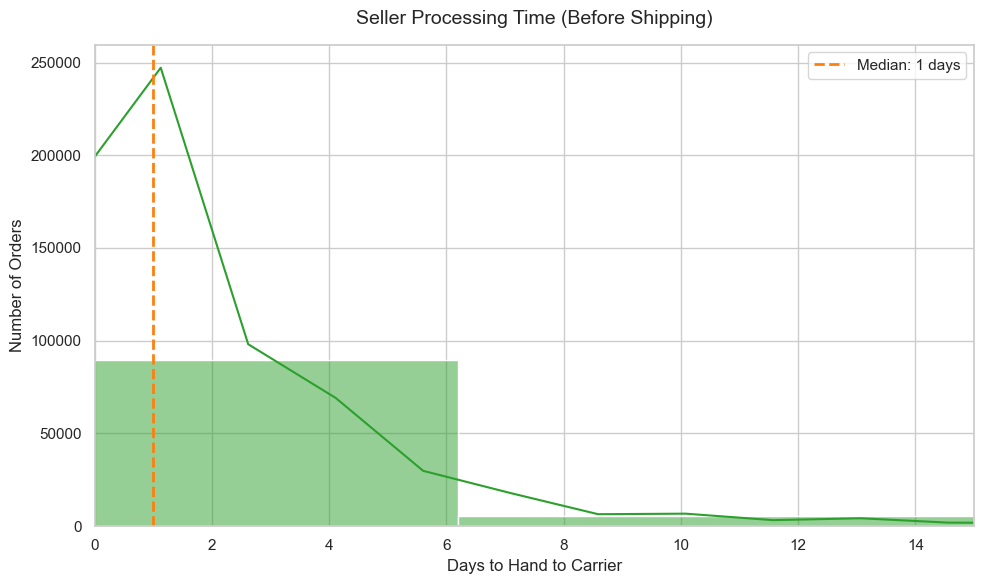


--- Generating AI Summary Dictionary ---
✅ AI Summary Dictionary successfully saved to ../outputs/ai_insights/eda_summary.json
total_revenue_brl: 15421082.85
total_delivered_orders: 96470
average_delivery_days: 12.1
median_delivery_days: 10.0
overall_average_review_score: 4.16
percentage_late_deliveries: 6.8
top_3_categories_by_revenue: ['health_beauty', 'watches_gifts', 'bed_bath_table']
single_order_customer_percentage: 97.0
median_seller_processing_days: 1.0


In [13]:
import json

# NOTE: the redundant re-conversion of order_delivered_carrier_date /
# order_approved_at that used to live here has been removed -- both
# columns are already proper datetimes from the setup cell at the top.

# ==========================================
# CHART 10: Seller Processing Time
# ==========================================
plt.figure(figsize=(10, 6))

# Calculate how long the seller took to hand it to the carrier
processing_time = df['order_delivered_carrier_date'] - df['order_approved_at']
df['seller_processing_days'] = processing_time.dt.days

# NOTE: previously this called .dropna() on the right-hand side before
# assigning back into df['seller_processing_days']. That does nothing --
# pandas re-aligns by index on assignment, so the NaNs come right back.
# The column itself is left with NaNs where the carrier-handoff date is
# missing (undelivered/cancelled orders); that's fine, but it means any
# code using this column needs to handle nulls explicitly rather than
# assuming the column was already cleaned. Doing that explicitly here:
processing_data = df['seller_processing_days'].dropna()

sns.histplot(processing_data, bins=30, color=accent_color, kde=True)
plt.axvline(processing_data.median(), color=danger_color, linestyle='dashed', 
            linewidth=2, label=f"Median: {processing_data.median():.0f} days")

plt.title('Seller Processing Time (Before Shipping)', fontsize=14, pad=15)
plt.xlabel('Days to Hand to Carrier')
plt.ylabel('Number of Orders')
plt.xlim(0, 15)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/10_seller_processing.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# EXPORT EDA SUMMARY FOR THE AI (Phase 15 Prep)
# ==========================================
print("\n--- Generating AI Summary Dictionary ---")

eda_summary = {
    "total_revenue_brl": round(df['revenue_per_order'].sum(), 2),
    "total_delivered_orders": len(df),
    "average_delivery_days": round(df['delivery_days'].mean(), 1),
    "median_delivery_days": round(df['delivery_days'].median(), 1),
    "overall_average_review_score": round(df['review_score'].mean(), 2),
    "percentage_late_deliveries": round((df['is_late'].sum() / len(df)) * 100, 1),
    "top_3_categories_by_revenue": df.groupby('product_category_name_english')['revenue_per_order'].sum().nlargest(3).index.tolist(),
    "single_order_customer_percentage": round(single_order_pct, 1),
    "median_seller_processing_days": round(processing_data.median(), 1)
}

os.makedirs('../outputs/ai_insights', exist_ok=True)
summary_path = '../outputs/ai_insights/eda_summary.json'

with open(summary_path, 'w') as f:
    json.dump(eda_summary, f, indent=4)

print(f"\u2705 AI Summary Dictionary successfully saved to {summary_path}")
for key, value in eda_summary.items():
    print(f"{key}: {value}")

ModuleNotFoundError: No module named 'config'